In [1]:
from pathlib import Path
from datetime import datetime, timedelta
import time

import requests
import numpy as np
import pandas as pd
import xarray as xr
import rioxarray as rxr
import matplotlib.pyplot as plt
import cartopy 
import cartopy.crs as ccrs
import cartopy.feature as cfeature

In [21]:
ds = xr.open_dataset('data/intermediate/eddi_04wk_2017_region.nc')

In [22]:
ds.load()

eddi_04wk = ds['EDDI_04wk']

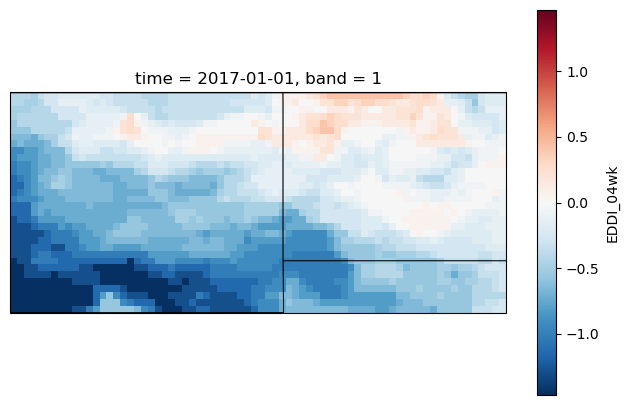

In [23]:
fig, ax = plt.subplots(figsize=(8, 5), subplot_kw={'projection': ccrs.PlateCarree()})
eddi_04wk.isel(time=0).plot()
ax.add_feature(cfeature.STATES, linewidth=0.5)
ax.add_feature(cfeature.BORDERS, linewidth=0.8)
ax.add_feature(cfeature.COASTLINE)

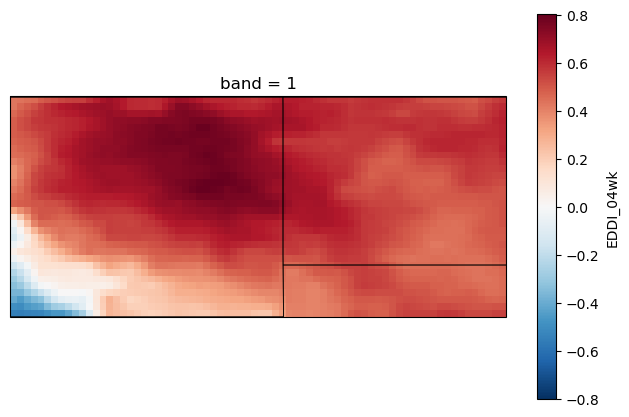

In [24]:
fig, ax = plt.subplots(figsize=(8, 5), subplot_kw={'projection': ccrs.PlateCarree()})
eddi_04wk.mean(dim='time').plot()

ax.add_feature(cfeature.STATES, linewidth=0.5)
ax.add_feature(cfeature.BORDERS, linewidth=0.8)
ax.add_feature(cfeature.COASTLINE)

In [25]:
eddi_04wk

<xarray.DataArray 'EDDI_04wk' (time: 365, lat: 32, lon: 72)> Size: 7MB
array([[[-4.13647413e-01, -4.13647413e-01, -4.13647413e-01, ...,
         -2.02107310e-01, -2.02107310e-01, -2.02107310e-01],
        [-4.13647413e-01, -4.13647413e-01, -4.88029718e-01, ...,
         -2.02107310e-01, -2.02107310e-01, -2.02107310e-01],
        [-4.88029718e-01, -4.88029718e-01, -4.88029718e-01, ...,
         -1.34069562e-01, -1.34069562e-01, -1.34069562e-01],
        ...,
        [-1.46481431e+00, -1.46481431e+00, -1.46481431e+00, ...,
         -4.13647413e-01, -4.13647413e-01, -4.13647413e-01],
        [-1.46481431e+00, -1.46481431e+00, -1.46481431e+00, ...,
         -3.41509104e-01, -3.41509104e-01, -2.71133065e-01],
        [-1.46481431e+00, -1.46481431e+00, -1.46481431e+00, ...,
         -3.41509104e-01, -2.71133065e-01, -2.71133065e-01]],

       [[-4.13647413e-01, -4.13647413e-01, -4.13647413e-01, ...,
         -1.34069562e-01, -1.34069562e-01, -6.66908026e-02],
        [-4.13647413e-01, -4.88029718e-01, -4.88029718e-01, ...,
         -1.34069562e-01, -6.66908026e-02,  3.34739685e-04],
        [-4.88029718e-01, -4.88029718e-01, -4.88029718e-01, ...,
         -1.34069562e-01, -1.34069562e-01,  3.34739685e-04],
...
          1.15124929e+00,  1.02949953e+00,  1.02949953e+00],
        [ 6.73623085e-02,  1.34745955e-01,  3.42221022e-01, ...,
          1.15124929e+00,  1.15124929e+00,  1.15124929e+00],
        [ 2.02791929e-01,  2.02791929e-01,  2.71829486e-01, ...,
          1.15124929e+00,  1.15124929e+00,  1.15124929e+00]],

       [[ 1.46677959e+00,  1.46677959e+00,  1.46677959e+00, ...,
          6.73623085e-02,  3.34739685e-04,  6.73623085e-02],
        [ 1.46677959e+00,  1.46677959e+00,  1.46677959e+00, ...,
          4.88786697e-01,  4.14379239e-01,  2.02791929e-01],
        [ 1.70140982e+00,  1.70140982e+00,  1.70140982e+00, ...,
          1.02949953e+00,  1.02949953e+00,  1.02949953e+00],
        ...,
        [-2.71133065e-01, -6.66908026e-02,  6.73623085e-02, ...,
          1.02949953e+00,  1.02949953e+00,  1.02949953e+00],
        [-1.34069562e-01, -6.66908026e-02,  1.34745955e-01, ...,
          1.02949953e+00,  1.02949953e+00,  9.21349049e-01],
        [ 3.34739685e-04,  3.34739685e-04,  3.34739685e-04, ...,
          1.02949953e+00,  9.21349049e-01,  9.21349049e-01]]],
      shape=(365, 32, 72))
Coordinates:
  * time     (time) datetime64[ns] 3kB 2017-01-01 2017-01-02 ... 2017-12-31
    band     int64 8B 1
  * lon      (lon) float64 576B -108.9 -108.8 -108.7 ... -100.3 -100.2 -100.1
  * lat      (lat) float64 256B 48.94 48.81 48.69 48.56 ... 45.31 45.19 45.06
Attributes:
    grid_mapping:  spatial_ref

In [18]:
#eddi_04wk = eddi_04wk.sel(time=slice("2017-01-01", "2017-12-31"))

In [26]:
eddi_regional_mean = eddi_04wk.mean(dim=("lat", "lon"))
eddi_regional_mean = eddi_regional_mean.reset_coords("band", drop=True)

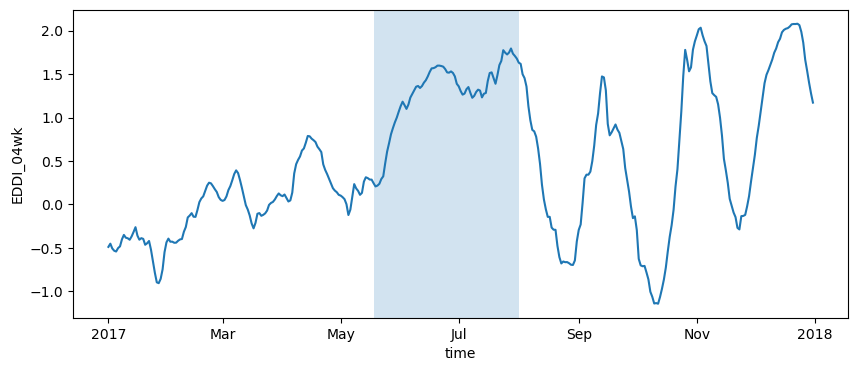

In [29]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10,4))

eddi_regional_mean.plot(ax=ax)

# Highlight Sept–Dec
ax.axvspan("2017-05-18", "2017-08-01", alpha=0.2)

plt.show()

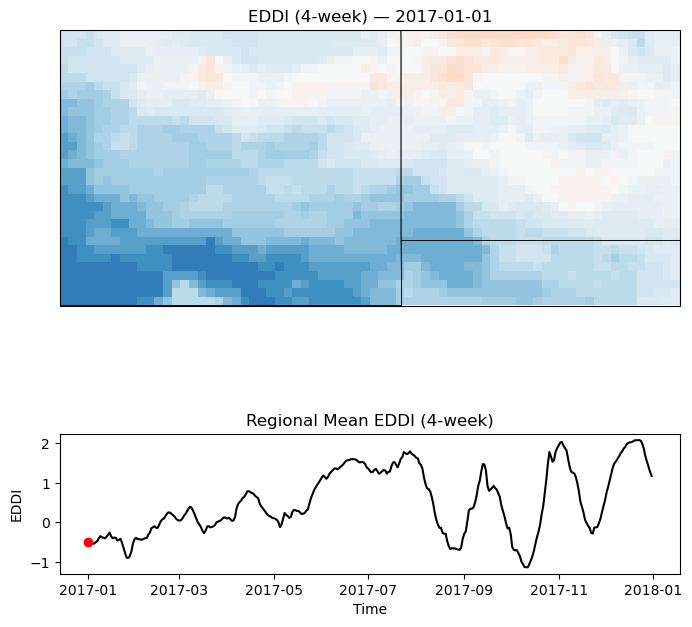

In [31]:
import matplotlib.pyplot as plt
import matplotlib.animation as animation
import cartopy.crs as ccrs
import cartopy.feature as cfeature

# use your 4-week EDDI data
eddi = eddi_04wk

# optional: subset time window to match your analysis period
eddi = eddi.sel(time=slice("2017-01-01", "2017-12-31"))

# regional mean time series
eddi_mean = eddi.mean(dim=("lat", "lon"))

# consistent color scale
vmin = float(eddi.min())
vmax = float(eddi.max())

# figure layout: map on top, time series below
fig = plt.figure(figsize=(8, 8))
gs = fig.add_gridspec(2, 1, height_ratios=[3, 1])

# --- map axis ---
ax_map = fig.add_subplot(gs[0], projection=ccrs.PlateCarree())

# --- time series axis ---
ax_ts = fig.add_subplot(gs[1])

# static full time series
ax_ts.plot(eddi_mean.time, eddi_mean, color='black')
dot, = ax_ts.plot([], [], 'ro')  # moving point

ax_ts.set_title("Regional Mean EDDI (4-week)")
ax_ts.set_xlabel("Time")
ax_ts.set_ylabel("EDDI")

# draw first frame once so colorbar can be attached
im = eddi.isel(time=0).plot(
    ax=ax_map,
    transform=ccrs.PlateCarree(),
    cmap='RdBu_r',
    vmin=vmin,
    vmax=vmax,
    add_colorbar=False
)

ax_map.add_feature(cfeature.STATES, linewidth=0.5)
ax_map.add_feature(cfeature.BORDERS, linewidth=0.8)
ax_map.add_feature(cfeature.COASTLINE)
ax_map.set_extent([-109, -100, 45, 49])

#cbar = plt.colorbar(im, ax=ax_map, orientation='horizontal', pad=0.05)
#cbar.set_label("EDDI")

def update(frame):
    ax_map.clear()

    # map
    eddi.isel(time=frame).plot(
        ax=ax_map,
        transform=ccrs.PlateCarree(),
        cmap='RdBu_r',
        vmin=vmin,
        vmax=vmax,
        add_colorbar=False
    )

    ax_map.add_feature(cfeature.STATES, linewidth=0.5)
    ax_map.add_feature(cfeature.BORDERS, linewidth=0.8)
    ax_map.add_feature(cfeature.COASTLINE)
    ax_map.set_extent([-109, -100, 45, 49])

    date = str(eddi.time.isel(time=frame).values)[:10]
    ax_map.set_title(f"EDDI (4-week) — {date}")

    # moving dot on time series
    dot.set_data(
        [eddi_mean.time.isel(time=frame).values],
        [eddi_mean.isel(time=frame).values]
    )

    return dot,

ani = animation.FuncAnimation(
    fig,
    update,
    frames=range(0, eddi.sizes["time"], 8),
    interval=600
)

ani.save("2017_eddi_4wkmap_timeseries_both.gif", writer="pillow", fps=4)